In [ ]:
import os
import random
import librosa
import numpy as np
import sounddevice as sd
from scipy.io.wavfile import write
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import load_model
import sys
sys.path.append(os.path.abspath('..'))
from config import DATA_PATH, PROCESSED_DATA_PATH, MODEL_SAVE_PATH, SENTENCES, SAMPLE_RATE, DURATION, N_MFCC

In [132]:
!pip install pyaudio

zsh:1: /Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/.venv/bin/pip: bad interpreter: /Users/ayamkattel/Desktop/Nepali-Speech-Recognition/.venv/bin/python3.13: no such file or directory


In [160]:
import os
import time
import librosa
import numpy as np
import pyaudio
import joblib
from tensorflow.keras.models import load_model


SAMPLE_RATE = 22050
DURATION = 4.224
FRAME_LENGTH = 2048
HOP_LENGTH = 512


MODEL_PATH = 'nepali_model_artifacts/nepali_lstm_model.h5'
SCALER_PATH = 'nepali_model_artifacts/scaler.joblib'
ENCODER_PATH = 'nepali_model_artifacts/label_encoder.joblib'


print("Loading Model, Scaler, and Encoder...")
try:
    model = load_model(MODEL_PATH)
    scaler = joblib.load(SCALER_PATH)
    le = joblib.load(ENCODER_PATH)
    print(" All artifacts loaded successfully!\n")
except Exception as e:
    print(f" Error loading artifacts: {e}")
    print("Please ensure the artifacts folder is in the same directory as this script.")
    exit()


def process_live_audio(audio, sample_rate):
    audio, _ = librosa.effects.trim(audio, top_db=20)
    if len(audio) > 0:
        audio = librosa.util.normalize(audio)
        
    target_length = int(sample_rate * DURATION)
    if len(audio) < target_length:
        audio = np.pad(audio, (0, max(0, target_length - len(audio))), "constant")
    else:
        audio = audio[:target_length]
    
    zcr_val = librosa.feature.zero_crossing_rate(audio, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH).T
    rmse_val = librosa.feature.rms(y=audio, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH).T
    mfcc_val = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=13, hop_length=HOP_LENGTH).T
    
    sequence = np.hstack((zcr_val, rmse_val, mfcc_val))
    return sequence

def record_audio_mac(duration=DURATION, target_sr=SAMPLE_RATE):
    p = pyaudio.PyAudio()
    
    RATE = 44100 
    CHANNELS = 1 
    DEVICE_INDEX = 1 
    
    CHUNK = 1024
    FORMAT = pyaudio.paFloat32

    print(f" RECORDING FOR {duration} SECONDS... ")
    
    stream = p.open(format=FORMAT, 
                    channels=CHANNELS, 
                    rate=RATE, 
                    input=True, 
                    input_device_index=DEVICE_INDEX,
                    frames_per_buffer=CHUNK)

    frames = []

    for i in range(0, int(RATE / CHUNK * duration)):
        data = stream.read(CHUNK, exception_on_overflow=False)
        frames.append(np.frombuffer(data, dtype=np.float32))

    print("Recording complete. Processing...\n")

    stream.stop_stream()
    stream.close()
    p.terminate()

    audio_data = np.hstack(frames)

    if RATE != target_sr:
        audio_data = librosa.resample(y=audio_data, orig_sr=RATE, target_sr=target_sr)

    return audio_data

def live_predict():
    print("Get ready to speak...")
    time.sleep(1)
    
    audio = record_audio_mac()
    
    features = process_live_audio(audio, SAMPLE_RATE)
    
    features_scaled = scaler.transform(features)
    
    lstm_input = np.expand_dims(features_scaled, axis=0)
    
    predictions = model.predict(lstm_input, verbose=0)
    predicted_index = np.argmax(predictions, axis=1)[0]
    confidence = np.max(predictions) * 100
    
    predicted_word = le.inverse_transform([predicted_index])[0]
    print("         LIVE PREDICTION RESULT         ")
    print(f"  Predicted:  {predicted_word}")
    print(f"  Confidence: {confidence:.2f}%")



Loading Model, Scaler, and Encoder...
 All artifacts loaded successfully!



/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/.venv/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/.venv/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [161]:
if __name__ == "__main__":
    while True:
        live_predict()
        
        user_input = input("Press ENTER to record again, or type 'q' to quit: ")
        if user_input.lower() == 'q':
            break

Get ready to speak...
 RECORDING FOR 4.224 SECONDS... 
Recording complete. Processing...

         LIVE PREDICTION RESULT         
  Predicted:  Ram_Le_Vaat_Khanxa
  Confidence: 85.25%
Get ready to speak...
 RECORDING FOR 4.224 SECONDS... 
Recording complete. Processing...

         LIVE PREDICTION RESULT         
  Predicted:  Tapaiko_Ghar_Kaha_Xa
  Confidence: 99.02%
Get ready to speak...
 RECORDING FOR 4.224 SECONDS... 
Recording complete. Processing...

         LIVE PREDICTION RESULT         
  Predicted:  Tapaiko_Ghar_Kaha_Xa
  Confidence: 95.62%
Get ready to speak...
 RECORDING FOR 4.224 SECONDS... 
Recording complete. Processing...

         LIVE PREDICTION RESULT         
  Predicted:  Tapaiko_Ghar_Kaha_Xa
  Confidence: 95.44%
Get ready to speak...
 RECORDING FOR 4.224 SECONDS... 
Recording complete. Processing...

         LIVE PREDICTION RESULT         
  Predicted:  Yo_Hamro_AI_Ko_Project_ho
  Confidence: 79.62%


Loading model and artifacts...
Scanning: /Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/test/raw
Processing 5 files for: Ma_Khusi_Xu
Processing 5 files for: Malai_Mero_Desh_Pyaro_Lagxa


/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/.venv/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/.venv/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Processing 5 files for: Namaste
Processing 5 files for: Ram_Le_Vaat_Khanxa
Processing 5 files for: Tapaiko_Ghar_Kaha_Xa
Processing 5 files for: TimiLai_Kasto_Chha
Processing 5 files for: Uh_Mero_Mitra_Ho
Processing 5 files for: Yo_Hamro_AI_Ko_Project_ho
Running Inference...
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step  

Classification Report:
                             precision    recall  f1-score   support

                Ma_Khusi_Xu       0.50      1.00      0.67         5
Malai_Mero_Desh_Pyaro_Lagxa       1.00      0.40      0.57         5
                    Namaste       1.00      0.80      0.89         5
         Ram_Le_Vaat_Khanxa       0.62      1.00      0.77         5
       Tapaiko_Ghar_Kaha_Xa       0.60      0.60      0.60         5
         TimiLai_Kasto_Chha       1.00      1.00      1.00         5
           Uh_Mero_Mitra_Ho       0.75      0.60      0.67         5
  Yo_Hamro_AI_Ko_Project_ho       0.50      0.20      0.29         5

                   accuracy             

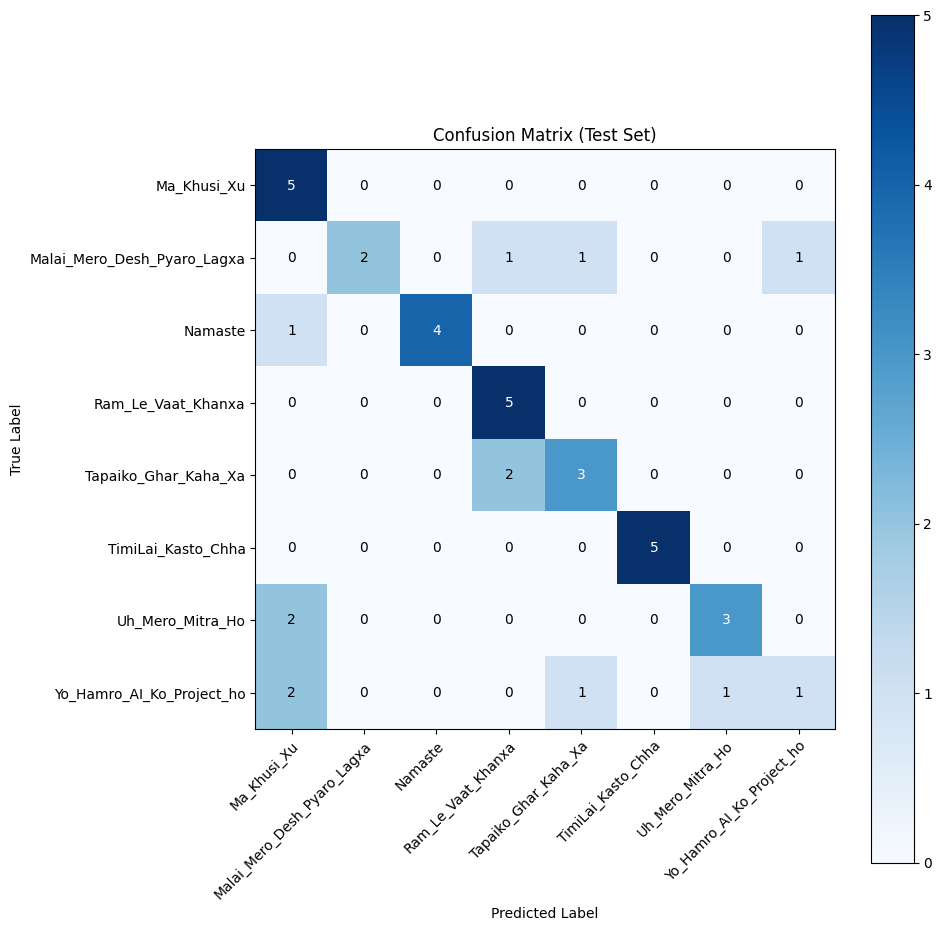

In [147]:
import os
import librosa
import numpy as np
import joblib
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# --- CONFIGURATION (Must match training constants) ---
TEST_DATA_PATH = "/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/test/raw"
MODEL_PATH = '/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/nepali_model_artifacts/nepali_lstm_model.h5'
SCALER_PATH = '/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/nepali_model_artifacts/scaler.joblib'
ENCODER_PATH = '/Users/ayamkattel/Desktop/MISC_LATEST/Nepali-Speech-Recognition/nepali_model_artifacts/label_encoder.joblib'

SAMPLE_RATE = 22050
DURATION = 4.224
FRAME_LENGTH = 2048
HOP_LENGTH = 512
SENTENCES = [
    "Ma_Khusi_Xu", "Malai_Mero_Desh_Pyaro_Lagxa", "Namaste", 
    "Ram_Le_Vaat_Khanxa", "Tapaiko_Ghar_Kaha_Xa", "TimiLai_Kasto_Chha", 
    "Uh_Mero_Mitra_Ho", "Yo_Hamro_AI_Ko_Project_ho"
]

def process_audio_sequence(audio, sample_rate):
    # Standard preprocessing: Trim, Normalize, Pad/Truncate
    audio, _ = librosa.effects.trim(audio, top_db=20)
    if len(audio) > 0:
        audio = librosa.util.normalize(audio)
    
    target_length = int(sample_rate * DURATION)
    if len(audio) < target_length:
        audio = np.pad(audio, (0, max(0, target_length - len(audio))), "constant")
    else:
        audio = audio[:target_length]
    
    # Feature extraction
    zcr = librosa.feature.zero_crossing_rate(audio, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH).T
    rmse = librosa.feature.rms(y=audio, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH).T
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=13, hop_length=HOP_LENGTH).T
    
    return np.hstack((zcr, rmse, mfcc))

def test_model():
    # 1. Load Artifacts
    print("Loading model and artifacts...")
    model = tf.keras.models.load_model(MODEL_PATH)
    scaler = joblib.load(SCALER_PATH)
    le = joblib.load(ENCODER_PATH)

    x_test_list = []
    y_test_list = []

    # 2. Iterate through local test directory
    print(f"Scanning: {TEST_DATA_PATH}")
    for category in SENTENCES:
        folder_path = os.path.join(TEST_DATA_PATH, category)
        if not os.path.exists(folder_path):
            continue
            
        files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
        print(f"Processing {len(files)} files for: {category}")
        
        for file in files:
            file_path = os.path.join(folder_path, file)
            audio, sr = librosa.load(file_path, sr=SAMPLE_RATE)
            features = process_audio_sequence(audio, sr)
            x_test_list.append(features)
            y_test_list.append(category)

    X_test = np.array(x_test_list)
    Y_true_labels = np.array(y_test_list)

    # 3. Scaling (Consistent with Kaggle logic)
    samples, steps, features = X_test.shape
    X_reshaped = X_test.reshape(-1, features)
    X_scaled = scaler.transform(X_reshaped) 
    X_final = X_scaled.reshape(samples, steps, features)

    # 4. Predict
    print("Running Inference...")
    preds = model.predict(X_final)
    pred_indices = np.argmax(preds, axis=1)
    pred_labels = le.inverse_transform(pred_indices)

    # 5. Report
    print("\nClassification Report:")
    print(classification_report(Y_true_labels, pred_labels))

    # 6. Confusion Matrix using Matplotlib
    cm = confusion_matrix(Y_true_labels, pred_labels)
    classes = le.classes_

    fig, ax = plt.subplots(figsize=(10, 10))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    
    # Set labels
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=classes, yticklabels=classes,
           title='Confusion Matrix (Test Set)',
           ylabel='True Label',
           xlabel='Predicted Label')

    # Rotate labels for readability
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Annotate cells with numbers
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

    fig.tight_layout()
    plt.show()

if __name__ == "__main__":
    test_model()